In [2]:
import numpy as np

# Parametros del la simulación
n_3      = 0.1
r        = np.linspace(0,1.5,16)
divisor  = 40
        
# Diametro de los cilindros
sigma_3  = 1.0
sigma_2  = 10.0  * sigma_3
sigma_1  = 10.0  * sigma_3

# Altura de los cilindros
h_1      = 10.0  * sigma_3
h_2      = np.linspace(2,10,5)* sigma_3
         
# Dimensiones del sistema
delta_x  = sigma_3/divisor

# Elementos del mallado
x       = np.arange( sigma_2/2 - 3*sigma_3 ,   sigma_2/2 + 4*sigma_3   , delta_x)
y       = np.arange(      -3*sigma_3       ,       3*sigma_3           , delta_x)
z       = np.arange(  -(h_1+sigma_3)/2     , (h_1+sigma_3)/2+delta_x   , delta_x)

# Arrays del mallado
xx, yy, zz = np.meshgrid(x, y, z, sparse=False)

# Ubicación de las esferas 2
X_1      = np.array([0,0,0])

In [12]:
import time
# Verificar velocidad de ejecución
inicio = time.time()

def sqrt_mod(x):
    mask = x <= 0
    x[mask] = 0
    x = np.sqrt(x)
    return x

#Inicializar donde se guardara el número de traslapes
num_tras = np.zeros((len(h_2),len(r)))

#Calcular iterativamente todos los valores de los traslapes
for j in range(len(h_2)):
    for i in range(len(r)):   
        # Ubicación de las esferas 2
        X_2         =  np.array([(sigma_1+sigma_2)/2 + r[i]*sigma_3 ,0,0])
        
        # Proyección en el plano xy 
        ####################################################################################################################
        # Arrays con la distancia entre el cilindro 1 y cada punto del mallado                                             #
        d1          =   np.sqrt( (X_1[0]-xx)**2 + (X_1[1]-yy)**2 )                                                         #
        # Filtros que identifican si hay traslape entre los cilindros y las pequeñas esferas del mallado                   #
        # Son un array de boleanos                                                                                         #
        # Filtro para el traslape en -h_2/2 < z < h_2/2                                                                    #
        mask_1      =  d1  <= (sigma_1+sigma_3)/2                                                                          #
        # Filtro para el traslape en -(h_2 + sigma_3)/2 < z < -h_2/2                                                       #
        mask_3      =  d1  <= sigma_1/2  + sqrt_mod( sigma_3**2 / 4 - (- h_2[j]/2 - zz)**2 )                               #
        # Filtro para el traslape en h_2/2 < z < (h_2 + sigma_3)/2                                                         #
        mask_5      =  d1  <= sigma_1/2  + sqrt_mod( sigma_3**2 / 4 - ( h_2[j]/2 - zz)**2 )                                #
        del(d1)        # Eliminar un gran array para ahorrar memoria                                                       #
        ####################################################################################################################
        
        #################################################################################################################### 
        # Repetir para el cilindro 2                                                                                       #
        d2          =  np.sqrt( (X_2[0]-xx)**2 + (X_2[1]-yy)**2 )                                                          #
        # Filtro para el traslape en -h_2/2 < z < h_2/2                                                                    #
        mask_2      =  d2 <= (sigma_2+sigma_3)/2                                                                           #
        # Filtro para el traslape en -(h_2 + sigma_3)/2 < z < -h_2/2                                                       #
        mask_4      =  d2 <= sigma_2/2  + sqrt_mod( sigma_3**2 / 4 - (-h_2[j]/2 - zz)**2 )                                 #
        # Filtro para el traslape en h_2/2 < z < (h_2 + sigma_3)/2                                                         #
        mask_6      =  d2 <= sigma_2/2  + sqrt_mod( sigma_3**2 / 4 - ( h_2[j]/2 - zz )**2 )                                #
        del(d2)        # Eliminar un gran array para ahorrar memoria                                                       #
        #################################################################################################################### 
                  
        # Combinación de filtros en xy
        #################################################################################################################### 
        mask_xy_1   =  mask_1 & mask_2                                                                                     #
        mask_xy_2   =  mask_3 & mask_4                                                                                     #
        mask_xy_3   =  mask_5 & mask_6                                                                                     #
        del(mask_1,mask_2,mask_3,mask_4,mask_5,mask_6)                                                                     #
        ####################################################################################################################
        
        # Filtros en el plano zx
        ####################################################################################################################
        # Filtro de altura en -h_2/2 < z < h_2/2                                                                           #
        mask_1      =  -h_2[j]/2   <  zz                                                                                   #
        mask_2      =      zz      <  h_2[j]/2                                                                             #
        mask_h_1    =  mask_1      &  mask_2      #Condición junto con mask_xy_1 para el traslape                          #
        del(mask_1,mask_2)                                                                                                 #
        ####################################################################################################################
        
        ####################################################################################################################
        # Filtro de altura en -(h_2+sigma_3)/2 < z < -h_2/2                                                                #
        mask_1      =  -(h_2[j]+sigma_3)/2   <  zz                                                                         #
        mask_2      =      zz      <  -h_2[j]/2                                                                            #
        mask_h_2    =  mask_1  &  mask_2          #Condición junto con mask_xy_2 para el traslape                          #
        del(mask_1,mask_2)                                                                                                 #
        ####################################################################################################################
        
        ####################################################################################################################
        # Filtro de altura en h_2/2 < z < (h_2+sigma_3)/2                                                                  #
        mask_1      =   h_2[j]/2   <  zz                                                                                   #
        mask_2      =      zz      <  (h_2[j]+sigma_3)/2                                                                   #
        mask_h_3    =  mask_1  &  mask_2          #Condición junto con mask_xy_3 para el traslape                          #
        del(mask_1,mask_2)                                                                                                 #
        ####################################################################################################################
        
        # Filtro final
        mask        =  (mask_xy_1 & mask_h_1) | (mask_xy_2 & mask_h_2) | (mask_xy_3 & mask_h_3) 
        del(mask_xy_2,mask_xy_3,mask_h_1,mask_h_2,mask_h_3)
        
        # Número de elementos con traslape de ambas esferas
        num_tras[j,i] = len(mask[mask])
fin = time.time()
print(fin-inicio) # Medir cuanto dura el proceso con finalidades de optimización

beta_u_ef =  -num_tras*n_3*(delta_x**3)
np.savetxt("beta_u_cil_delta_x_"+str(divisor)+"_h_2.csv", beta_u_ef, delimiter=",")

49.17622780799866


In [3]:
def beta_u_fun(n_3,sigma_3,sigma_1,sigma_2,r,h_2):
    phi_3     = n_3 * (sigma_3**2) * np.pi / 4 
    eta_1     = sigma_1/sigma_3
    eta_2     = sigma_2/sigma_3

    resultado = np.zeros(len(r))

    for i in range(len(r)):
        R_red        = r[i] + (sigma_1 + sigma_2) / 2
        r_1          = (sigma_3/(4*R_red)) * (  4*(R_red/sigma_3)**2 + ( 1+eta_1 )**2 - (1+eta_2)**2 )
        r_2          = (2*R_red)/sigma_3 -r_1

        if r[i] > sigma_3: 
            resultado[i] = 0
        else:
            resultado[i] = (- (phi_3/np.pi) * (1+eta_1)**2 * ( np.arccos( r_1/(1+eta_1) ) - (r_1/(1+eta_1))*np.sqrt( 1 - ( r_1/( 1+eta_1 ))**2 ) ) 
                            - (phi_3/np.pi) * (1+eta_2)**2 * ( np.arccos( r_2/(1+eta_2) ) - (r_2/(1+eta_2))*np.sqrt( 1 - ( r_2/( 1+eta_2 ))**2 ) ) )
        
    return    resultado*h_2

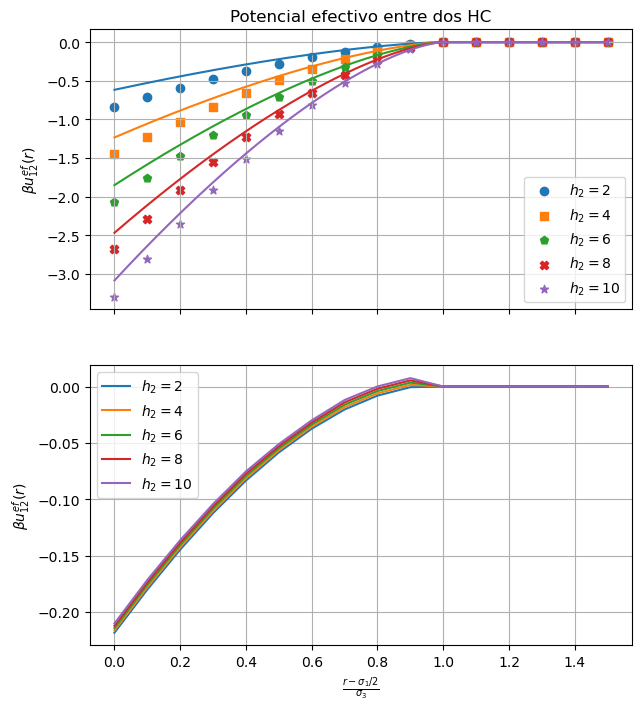

In [5]:
import matplotlib.pyplot as plt

beta_u_ef = np.loadtxt("beta_u_cil_delta_x_40_h_2.csv", delimiter=",")

fig, axs = plt.subplots(2,1, sharex=True,figsize=[7, 8])

r1  = np.linspace(0,1.5,1000)*sigma_3

markers = ['o','s','p',"X","*"]
for j in range(len(h_2)):
    axs[0].scatter( r , beta_u_ef[j], label=r'$h_2=$'+str(int(h_2[j])), marker= markers[j])
    axs[0].plot(   r1 , beta_u_fun( n_3,sigma_3,sigma_1,sigma_2,r1,h_2[j]) )
    
    axs[1].plot(r, beta_u_ef[j]- beta_u_fun( n_3,sigma_3,sigma_1,sigma_2,r,h_2[j] ), label=r'$h_2=$'+str(int(h_2[j])) )

axs[0].set_title('Potencial efectivo entre dos HC')
axs[0].set_ylabel(r'$\beta u_{12}^{ef}(r)$')
axs[1].set_ylabel(r'$\beta u_{12}^{ef}(r)$')
axs[1].set_xlabel(r'$\frac{r - \sigma_1 / 2}{\sigma_3}$')
axs[0].legend()
axs[1].legend()
axs[0].grid(True)
axs[1].grid(True)
plt.savefig("Grafico_cilindros_h_2.png", dpi=500)
plt.show()

